# Aluno: Artur Kohara Guerra
# Fundamentos de Desenvolvimento e Aprendizado

---

# Lista 1

## 5. Regressão linear no conjunto *Palmer Penguins*.

Considere o conjunto de dados *Palmer Penguins*. Utilize **body_mass_g** como variável
resposta e **bill_length_mm**, **bill_depth_mm** e **flipper_length_mm** como variáveis explicativas. Remova as observações que contenham valores ausentes. Utilizando a linguagem
de programação e as bibliotecas de sua preferência, faça o que se pede.

### a) Separe os dados em um conjunto de treinamento e um conjunto de teste.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
penguins = sns.load_dataset('penguins')

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
target = 'body_mass_g'
all_cols = features + [target]

penguins_clean = penguins.dropna(subset=all_cols)

print(f"Dados originais: {penguins.shape[0]} linhas")
print(f"Dados após remover nulos: {penguins_clean.shape[0]} linhas")
display(penguins_clean.head())

Dados originais: 344 linhas
Dados após remover nulos: 342 linhas


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
split_ratio = 0.3
x = penguins_clean[features]
y = penguins_clean[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=split_ratio, random_state=42)

print(f"Conjunto de treinamento: {x_train.shape[0]} linhas")
print(f"Conjunto de teste: {x_test.shape[0]} linhas")

Conjunto de treinamento: 239 linhas
Conjunto de teste: 103 linhas


### b) Construa a matriz design e ajuste, aos dados de treinamento, o modelo abaixo. Para facilitar a leitura, considere **y = body_mass_g**, **x<sub>1</sub> = bill_length_mm**, **x<sub>2</sub> = bill_depth_mm**, **x<sub>3</sub> = flipper_length_mm**. Assim, o modelo pode ser escrito de forma compacta como $Y = β_0 + β_1x_1 + β_2x_2 + β_3x_3$.

In [ ]:
x_design_train = np.hstack([np.ones((x_train.shape[0], 1)), x_train.values])

columns_design = ['intercepto'] + features
x_design_df = pd.DataFrame(x_design_train, columns=columns_design, index=x_train.index)

print("Primeiras 5 linhas da matriz design do conjunto de treino:")
display(x_design_df.head())

model = LinearRegression(fit_intercept=True)
model.fit(x_train, y_train)

beta_0 = model.intercept_
beta_1, beta_2, beta_3 = model.coef_

Primeiras 5 linhas da matriz design do conjunto de treino:


,intercepto,bill_length_mm,bill_depth_mm,flipper_length_mm
32,1.0,39.5,17.8,188.0
245,1.0,46.1,15.1,215.0
229,1.0,46.8,15.4,215.0
176,1.0,46.7,17.9,195.0
250,1.0,47.3,15.3,222.0


### c) Apresente os parâmetros estimados e interprete o efeito de cada variável explicativa sobre o valor previsto de **body_mass_g**.

In [ ]:
print("Coeficientes Estimados:")
print(f"Beta 0 (Intercepto): {beta_0:.4f}")
print(f"Beta 1 (bill_length_mm): {beta_1:.4f}")
print(f"Beta 2 (bill_depth_mm): {beta_2:.4f}")
print(f"Beta 3 (flipper_length_mm): {beta_3:.4f}")

print("\nEquação do modelo ajustado:")
print(f"Y = {beta_0:.2f} + ({beta_1:.2f})x1 + ({beta_2:.2f})x2 + ({beta_3:.2f})x3")

Coeficientes Estimados:
Beta 0 (Intercepto): -5946.1327
Beta 1 (bill_length_mm): 4.4387
Beta 2 (bill_depth_mm): 11.1345
Beta 3 (flipper_length_mm): 48.5977

Equação do modelo ajustado:
Y = -5946.13 + (4.44)x1 + (11.13)x2 + (48.60)x3


As variáveis explicativas indicam quanto que cada variável influencia no peso do pinguim, sendo que os coeficientes estimados indicam a magnitude dessa influência quando as demais variáveis explicativas são mantidas constantes.

O intercepto, nesse contexto, não possui significado biológico ou físico real, pois não existe um pinguim com bico ou asa de tamanho zero. Logo, ele atua puramente como uma constante de ajuste matemático para posicionar a reta de regressão.

Cada aumento de 1 mm no comprimento do bico (bill_length_mm) está associado a um aumento médio de aproximadamente 4,44 gramas no peso previsto do pinguim.

Cada aumento de 1 mm na profundidade do bico (bill_depth_mm) está associado a um aumento médio de aproximadamente 11,13 gramas no peso previsto do pinguim.

Cada aumento de 1 mm no comprimento da asa (flipper_length_mm) está associado a um aumento médio expressivo de aproximadamente 48,60 gramas no peso previsto.

### d) Calcule as previsões e os resíduos para o conjunto de teste.

In [ ]:
y_test_pred = model.predict(x_test)

residuals = y_test - y_test_pred

test_results = pd.DataFrame({
    'Valor Real (y_test)': y_test,
    'Previsão (y_pred)': y_test_pred,
    'Resíduo (Erro)': residuals
})

print("Primeiras 10 previsões e resíduos no conjunto de teste:")
display(test_results.head(10))

Primeiras 10 previsões e resíduos no conjunto de teste:


,Valor Real (y_test),Previsão (y_pred),Resíduo (Erro)
238,4800.0,4577.306588,222.693412
117,3775.0,4118.631979,-343.631979
114,3900.0,3742.286375,157.713625
43,4400.0,3994.114656,405.885344
127,4300.0,3918.387920,381.612080
276,4300.0,4511.375215,-211.375215
183,4300.0,4294.182340,5.817660
180,3700.0,3740.179659,-40.179659
341,5750.0,5241.080790,508.919210
26,3550.0,3334.561020,215.438980


### e) Calcule o MSE e o R<sup>2</sup> do modelo tanto no conjunto de treinamento quanto no conjunto de teste. Compare os resultados.

In [ ]:
y_train_pred = model.predict(x_train)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Treinamento:")
print(f"- MSE: {mse_train:.2f}")
print(f"- R²:  {r2_train:.4f} ({r2_train * 100:.2f}%)")

print(f"\nTeste:")
print(f"- MSE: {mse_test:.2f}")
print(f"- R²:  {r2_test:.4f} ({r2_test * 100:.2f}%)")

diff_r2 = abs(r2_train - r2_test) * 100
print(f"\nDiferença absoluta entre o R² de treino e teste: {diff_r2:.2f} pontos percentuais")

Treinamento:
- MSE: 167121.95
- R²:  0.7354 (73.54%)

Teste:
- MSE: 121253.53
- R²:  0.8169 (81.69%)

Diferença absoluta entre o R² de treino e teste: 8.16 pontos percentuais


### f) Escolha uma das variáveis explicativas e produza um gráfico que auxilie na avaliação da adequação da relação linear assumida pelo modelo. Comente o resultado.

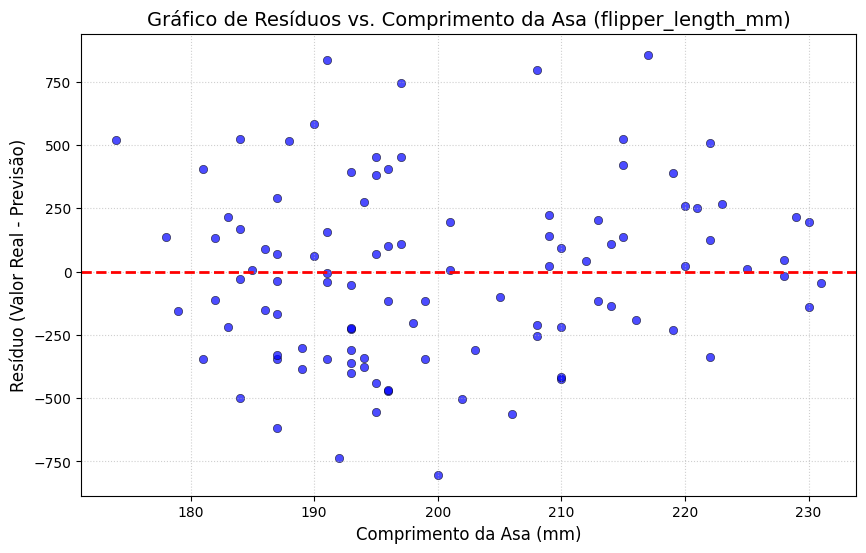

In [ ]:
x_var = x_test['flipper_length_mm']

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_var, y=residuals, color='blue', alpha=0.7, edgecolor='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Gráfico de Resíduos vs. Comprimento da Asa (flipper_length_mm)', fontsize=14)
plt.xlabel('Comprimento da Asa (mm)', fontsize=12)
plt.ylabel('Resíduo (Valor Real - Previsão)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Ao observar o gráfico, os pontos azuis (erros de previsão) estão dispersos de forma aleatória acima e abaixo da linha vermelha pontilhada, que representa o resíduo zero, ou seja, não há uma tendência visível de curva. A ausência de um padrão indica que a relação linear assumida pelo modelo é adequada para explicar a associação entre o comprimento da asa e o peso do pinguim.

É possível notar alguns poucos pontos com resíduos mais extremos (por exemplo, acima de 750 ou abaixo de -750), indicando espécimes cujo peso real foi subestimado ou superestimado pelo modelo. No entanto, a grande massa de dados está concentrada entre -500 e 500 gramas.

## 6. Regressão polinomial no conjunto *Palmer Penguins*.

Ainda utilizando o conjunto de dados *Palmer Penguins*, investigue se a relação entre
**flipper_length_mm** e **body_mass_g** pode ser melhor representada por uma regressão
polinomial. Utilize a linguagem de programação e as bibliotecas de sua preferência.

### a) Divida os dados em conjuntos de treinamento, validação e teste. O conjunto de teste não deve ser utilizado durante a escolha do modelo

In [ ]:
split_ratio_test = 0.1

x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=split_ratio_test, random_state=42)

split_ratio_valid = 0.2 / (1.0 - split_ratio_test)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=split_ratio_valid, random_state=42)

print(f"Conjunto de treinamento: {x_train.shape[0]} linhas")
print(f"Conjunto de validação: {x_valid.shape[0]} linhas")
print(f"Conjunto de teste: {x_test.shape[0]} linhas")

Conjunto de treinamento: 238 linhas
Conjunto de validação: 69 linhas
Conjunto de teste: 35 linhas


### b) Ajuste modelos para diferentes valores do grau *d*. Para facilitar a leitura, considere **y = body_mass_g**, **x<sub>1</sub> = flipper_length_mm**, **x<sub>2</sub> = bill_length_mm**, **x<sub>3</sub> = bill_depth_mm**. O modelo a ser ajustado é $ Y = β_0 + ∑_{j=1}^d β_jx_1^j + β_{d+1}x_2 + β_{d+2}x_3$.

In [ ]:
x1_train, x1_valid = x_train['flipper_length_mm'], x_valid['flipper_length_mm']
x2_train, x2_valid = x_train['bill_length_mm'], x_valid['bill_length_mm']
x3_train, x3_valid = x_train['bill_depth_mm'], x_valid['bill_depth_mm']

results_poly = {}

degrees = range(1, 10)

for d in degrees:
    X_poly_train = np.column_stack([x1_train**j for j in range(1, d + 1)])
    X_features_train = np.column_stack([X_poly_train, x2_train, x3_train])

    X_poly_valid = np.column_stack([x1_valid**j for j in range(1, d + 1)])
    X_features_valid = np.column_stack([X_poly_valid, x2_valid, x3_valid])

    model_poly = LinearRegression(fit_intercept=True)
    model_poly.fit(X_features_train, y_train)

    y_train_pred_poly = model_poly.predict(X_features_train)
    y_valid_pred_poly = model_poly.predict(X_features_valid)

    mse_tr = mean_squared_error(y_train, y_train_pred_poly)
    mse_va = mean_squared_error(y_valid, y_valid_pred_poly)
    r2_tr = r2_score(y_train, y_train_pred_poly)
    r2_va = r2_score(y_valid, y_valid_pred_poly)

    results_poly[d] = {
        'model': model_poly,
        'mse_train': mse_tr,
        'mse_valid': mse_va,
        'r2_train': r2_tr,
        'r2_valid': r2_va
    }

    print(f"Grau d = {d}")
    print(f"Treino:     MSE = {mse_tr:.2f} | R² = {r2_tr:.4f}")
    print(f"Validação:  MSE = {mse_va:.2f} | R² = {r2_va:.4f}\n")

Grau d = 1
Treino:     MSE = 159470.02 | R² = 0.7536
Validação:  MSE = 152673.40 | R² = 0.7812

Grau d = 2
Treino:     MSE = 144386.41 | R² = 0.7769
Validação:  MSE = 148205.91 | R² = 0.7876

Grau d = 3
Treino:     MSE = 135823.89 | R² = 0.7901
Validação:  MSE = 146856.85 | R² = 0.7895

Grau d = 4
Treino:     MSE = 130878.41 | R² = 0.7977
Validação:  MSE = 145303.30 | R² = 0.7918

Grau d = 5
Treino:     MSE = 131194.78 | R² = 0.7973
Validação:  MSE = 144938.96 | R² = 0.7923

Grau d = 6
Treino:     MSE = 141250.28 | R² = 0.7817
Validação:  MSE = 142837.59 | R² = 0.7953

Grau d = 7
Treino:     MSE = 142804.70 | R² = 0.7793
Validação:  MSE = 145668.26 | R² = 0.7912

Grau d = 8
Treino:     MSE = 142819.85 | R² = 0.7793
Validação:  MSE = 145663.56 | R² = 0.7912

Grau d = 9
Treino:     MSE = 142830.46 | R² = 0.7793
Validação:  MSE = 145679.34 | R² = 0.7912



### c) Para cada grau considerado, calcule o erro nos conjuntos de treinamento e validação e construa um gráfico relacionando o grau do polinômio com os respectivos erros.

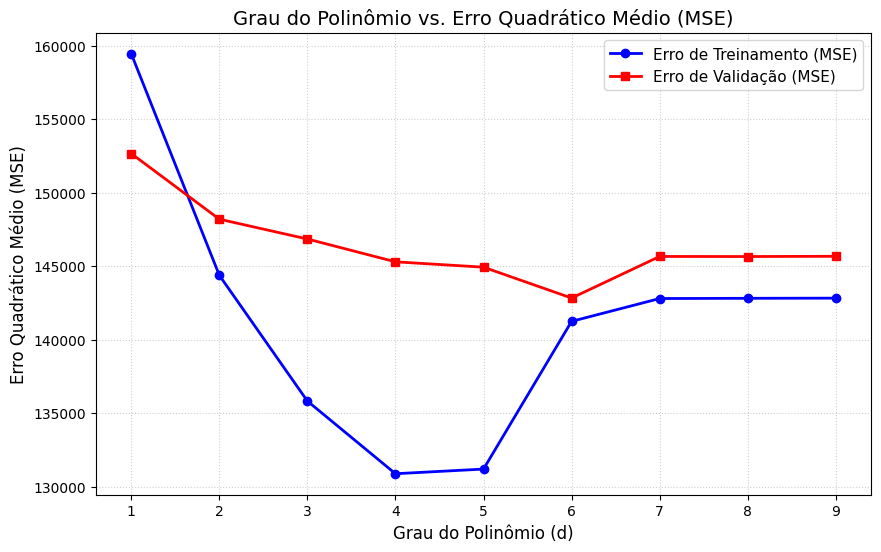

In [ ]:
degrees_plot = list(results_poly.keys())
mse_train = [results_poly[d]['mse_train'] for d in degrees_plot]
mse_valid = [results_poly[d]['mse_valid'] for d in degrees_plot]

plt.figure(figsize=(10, 6))
plt.plot(degrees_plot, mse_train, marker='o', linestyle='-', color='blue', label='Erro de Treinamento (MSE)', linewidth=2)
plt.plot(degrees_plot, mse_valid, marker='s', linestyle='-', color='red', label='Erro de Validação (MSE)', linewidth=2)

plt.title('Grau do Polinômio vs. Erro Quadrático Médio (MSE)', fontsize=14)
plt.xlabel('Grau do Polinômio (d)', fontsize=12)
plt.ylabel('Erro Quadrático Médio (MSE)', fontsize=12)
plt.xticks(degrees_plot)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

### d) A partir dos resultados obtidos, escolha um grau para o polinômio e justifique sua escolha. Identifique, quando possível, regiões associadas a subajuste (underfitting) e sobreajuste (overfitting).


A partir dos dados que foram obtidos no gráfico anterior, será escolhido o grau 4 para o polinômio, pois ele foi o grau que apresentou o menor erro de treinamento e um dos menores de validação, também. O grau 5 também possui desempenho bom e muito próximo ao grau 4, porém o ideal é escolher o modelo de menor complexidade.

Observando o gráfico, é possível identificar que graus muito baixos (abaixo de 4) ainda apresentam alta taxa de erros no treinamento e na validação, indicando underfitting. Quando aumentamos muito o grau do polinômio (grau 6 em diante), a taxa de erro aumenta novamente e se mantém constante à medida que o grau aumenta.

Nesse caso, não foi observado nenhum caso muito notável de overfitting, que ocorreria se houvesse algum modelo com taxa de erro baixa no treinamento e taxa de erro alta na validação.

### e) Após escolher o grau do polinômio, reajuste o modelo utilizando conjuntamente os dados de treinamento e validação. Somente então avalie seu desempenho no conjunto de teste utilizando MSE e R2.

In [ ]:
x1_temp = x_temp['flipper_length_mm']
x2_temp = x_temp['bill_length_mm']
x3_temp = x_temp['bill_depth_mm']

x_poly_temp = np.column_stack([x1_temp**j for j in range(1, 5)])
x_features_temp = np.column_stack([x_poly_temp, x2_temp, x3_temp])

model_final = LinearRegression(fit_intercept=True)
model_final.fit(x_features_temp, y_temp)

x1_test = x_test['flipper_length_mm']
x2_test = x_test['bill_length_mm']
x3_test = x_test['bill_depth_mm']

x_poly_test = np.column_stack([x1_test**j for j in range(1, 5)])
x_features_test = np.column_stack([x_poly_test, x2_test, x3_test])

y_test_pred_final = model_final.predict(x_features_test)

mse_test = mean_squared_error(y_test, y_test_pred_final)
r2_test = r2_score(y_test, y_test_pred_final)

print("Métricas finais do modelo polinomial (grau 4) no conjunto de teste:")
print(f"MSE: {mse_test:.2f}")
print(f"R²:  {r2_test:.4f} ({r2_test * 100:.2f}%)")

Métricas finais do modelo polinomial (grau 4) no conjunto de teste:
MSE: 110341.62
R²:  0.7628 (76.28%)


---

# Lista 2

## 4. Tuning, conjunto de validação e regularização

Nesta questão será utilizado o conjunto de dados **airquality**. Considere **Ozone** como variável resposta e **Temp**, **Wind** e **Solar.R** como variáveis preditoras.

### a) Divida os dados em três conjuntos: 60% para treinamento, 20% para validação e 20% para teste.(obs: Fixe uma semente aleatória para garantir a reprodutibilidade da divisão.)


In [99]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import Ridge

import statsmodels.api as sm

In [100]:
airquality = sm.datasets.get_rdataset("airquality", "datasets").data

features = ["Temp", "Wind", "Solar.R"]
target = "Ozone"
all_cols = features + [target]

airquality_clean = airquality.dropna(subset=all_cols)

print(f"Dados carregados: {airquality_clean.shape[0]} linhas e {airquality_clean.shape[1]} colunas")
display(airquality_clean.head())

Dados carregados: 111 linhas e 6 colunas


,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
6,23.0,299.0,8.6,65,5,7


In [101]:
split_ratio_test = 0.2
x = airquality_clean[features]
y = airquality_clean[target]

x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size=split_ratio_test, random_state=42)

split_ratio_valid = 0.2 / (1.0 - split_ratio_test)
x_train, x_valid, y_train, y_valid = train_test_split(x_temp, y_temp, test_size=split_ratio_valid, random_state=42)

print(f"Conjunto de treinamento: {x_train.shape[0]} linhas")
print(f"Conjunto de validação: {x_valid.shape[0]} linhas")
print(f"Conjunto de teste: {x_test.shape[0]} linhas")

Conjunto de treinamento: 66 linhas
Conjunto de validação: 22 linhas
Conjunto de teste: 23 linhas


### b) Considere modelos da forma $Ozone = β_0 + ∑_{j=1}^d β_jTemp^j + β_{d+1}Wind + β_{d+2}Solar.R + ϵ$. Considere o grau *d* como um hiperparâmetro e ajuste modelos para *d* = 1, 2, ..., 10. Utilize apenas o conjunto de treinamento para estimar os parâmetros e o conjunto de validação para escolher d.

In [102]:
Temp_train, Temp_valid = x_train['Temp'], x_valid['Temp']
Wind_train, Wind_valid = x_train['Wind'], x_valid['Wind']
Solar_train, Solar_valid = x_train['Solar.R'], x_valid['Solar.R']

results_poly = {}

degrees = range(1, 11)

for d in degrees:
    x_poly_train = np.column_stack([Temp_train**j for j in range(1, d + 1)])
    x_features_train = np.column_stack([x_poly_train, Wind_train, Solar_train])

    x_poly_valid = np.column_stack([Temp_valid**j for j in range(1, d + 1)])
    x_features_valid = np.column_stack([x_poly_valid, Wind_valid, Solar_valid])

    model_poly = LinearRegression(fit_intercept=True)
    model_poly.fit(x_features_train, y_train)

    y_train_pred_poly = model_poly.predict(x_features_train)
    y_valid_pred_poly = model_poly.predict(x_features_valid)

    rmse_va = root_mean_squared_error(y_valid, y_valid_pred_poly)
    r2_va = r2_score(y_valid, y_valid_pred_poly)

    intercept = model_poly.intercept_
    coefficients = model_poly.coef_

    results_poly[d] = {
        'model': model_poly,
        'rmse_valid': rmse_va,
        'r2_valid': r2_va
    }

    print(f"Grau d = {d}")
    print(f"Beta_0 (Intercepto): {intercept:.4f} | Beta_{d}: {coefficients[d]:.4f} | Beta_{d+1}: {coefficients[-2]:.4f} | Beta_{d+2}: {coefficients[-1]:.4f}")
    print(f"Validação:  RMSE = {rmse_va:.2f} | R² = {r2_va:.4f}\n")

Grau d = 1
Beta_0 (Intercepto): -66.7421 | Beta_1: -2.6390 | Beta_2: -2.6390 | Beta_3: 0.0687
Validação:  RMSE = 30.24 | R² = 0.4397

Grau d = 2
Beta_0 (Intercepto): 566.7428 | Beta_2: -2.2928 | Beta_3: -2.2928 | Beta_4: 0.0760
Validação:  RMSE = 30.93 | R² = 0.4140

Grau d = 3
Beta_0 (Intercepto): 1132.6981 | Beta_3: -2.3758 | Beta_4: -2.3758 | Beta_5: 0.0776
Validação:  RMSE = 30.75 | R² = 0.4206

Grau d = 4
Beta_0 (Intercepto): -8948.6707 | Beta_4: -2.3152 | Beta_5: -2.3152 | Beta_6: 0.0750
Validação:  RMSE = 30.94 | R² = 0.4134

Grau d = 5
Beta_0 (Intercepto): 37250.4195 | Beta_5: -2.3005 | Beta_6: -2.3005 | Beta_7: 0.0738
Validação:  RMSE = 31.08 | R² = 0.4081

Grau d = 6
Beta_0 (Intercepto): 6132.4448 | Beta_6: -2.2997 | Beta_7: -2.2997 | Beta_8: 0.0738
Validação:  RMSE = 31.11 | R² = 0.4070

Grau d = 7
Beta_0 (Intercepto): 1818.5491 | Beta_7: -2.3008 | Beta_8: -2.3008 | Beta_9: 0.0737
Validação:  RMSE = 31.14 | R² = 0.4061

Grau d = 8
Beta_0 (Intercepto): 505.7121 | Beta_8: 0.00

### c) Para cada valor de *d*, calcule o RMSE no conjunto de validação. Construa um gráfico apresentando o RMSE em função do grau do polinômio e indique qual grau seria escolhido.


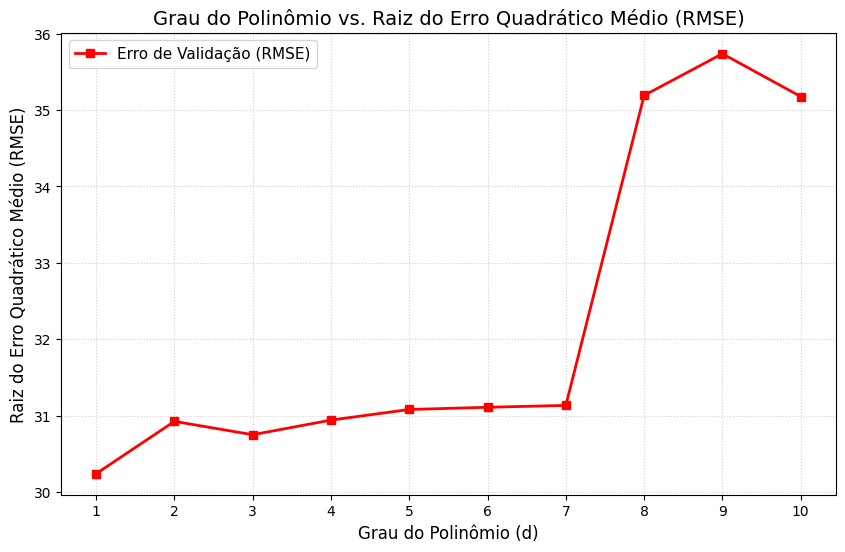

In [103]:
degrees_plot = list(results_poly.keys())
mse_valid = [results_poly[d]['rmse_valid'] for d in degrees_plot]

plt.figure(figsize=(10, 6))
plt.plot(degrees_plot, mse_valid, marker='s', linestyle='-', color='red', label='Erro de Validação (RMSE)', linewidth=2)

plt.title('Grau do Polinômio vs. Raiz do Erro Quadrático Médio (RMSE)', fontsize=14)
plt.xlabel('Grau do Polinômio (d)', fontsize=12)
plt.ylabel('Raiz do Erro Quadrático Médio (RMSE)', fontsize=12)
plt.xticks(degrees_plot)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

Dessa forma, percebe-se que seria escolhido o valor de *d* igual a 1, de acordo com os resultados obtidos na validação, pois esse grau foi o que apresentou menor RMSE, como pode ser visto no gráfico acima.

### e) Considere agora um polinômio de grau 10 para **Temp** e ajuste uma regressão Ridge, $SSE(β) + λ∑_{j=1}^pβ_j^2$. Considere $λ ∈ \{10^{-4}, 10^{-3}, ..., 10^3\}$. Utilizando o conjunto de validação, escolha o valor de λ que produz o menor RMSE.

In [104]:
degree = 10

x_poly_train_10 = np.column_stack([Temp_train**j for j in range(1, degree + 1)])
x_features_train_10 = np.column_stack([x_poly_train_10, Wind_train, Solar_train])

x_poly_valid_10 = np.column_stack([Temp_valid**j for j in range(1, degree + 1)])
x_features_valid_10 = np.column_stack([x_poly_valid_10, Wind_valid, Solar_valid])

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_features_train_10)
x_valid_scaled = scaler.transform(x_features_valid_10)

lambdas = [10**i for i in range(-4, 4)]

results_ridge = []

for lmbda in lambdas:
    model_ridge = Ridge(alpha=lmbda, random_state=42)
    model_ridge.fit(x_train_scaled, y_train)

    y_valid_pred = model_ridge.predict(x_valid_scaled)

    rmse_val = root_mean_squared_error(y_valid, y_valid_pred)

    results_ridge.append({
        'lambda': lmbda,
        'rmse_val': rmse_val,
        'model': model_ridge
    })

df_results = pd.DataFrame(results_ridge)

print("Resultados da Regressão Ridge por valor de Lambda:")
for idx, row in df_results.iterrows():
    print(f"λ = {row['lambda']:<8} | RMSE de Validação = {row['rmse_val']:.4f}")

Resultados da Regressão Ridge por valor de Lambda:
λ = 0.0001   | RMSE de Validação = 30.5781
λ = 0.001    | RMSE de Validação = 30.4177
λ = 0.01     | RMSE de Validação = 30.3517
λ = 0.1      | RMSE de Validação = 30.3445
λ = 1.0      | RMSE de Validação = 30.3943
λ = 10.0     | RMSE de Validação = 30.6601
λ = 100.0    | RMSE de Validação = 32.7386
λ = 1000.0   | RMSE de Validação = 37.8440


Dessa maneira, nota-se que o valor de λ que gera o menor RMSE é o λ igual a 0.1 (10<sup>-1</sup>).

### f) Construa um gráfico do RMSE de validação em função de λ, utilizando escala logarítmica no eixo correspondente a λ. Comente o comportamento observado para valores muito pequenos e muito grandes de λ.

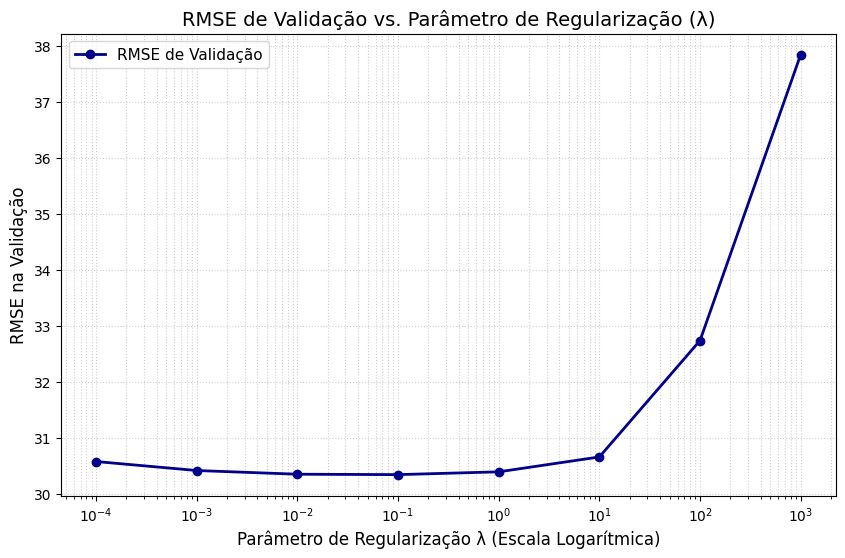

In [105]:
plt.figure(figsize=(10, 6))
plt.plot(df_results['lambda'], df_results['rmse_val'], marker='o', color='darkblue', linewidth=2, label='RMSE de Validação')

plt.xscale('log')

plt.title('RMSE de Validação vs. Parâmetro de Regularização (λ)', fontsize=14)
plt.xlabel('Parâmetro de Regularização λ (Escala Logarítmica)', fontsize=12)
plt.ylabel('RMSE na Validação', fontsize=12)
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

  Quando $\lambda$ é muito pequeno, a penalização imposta aos coeficientes é baixa. O modelo comporta-se quase como uma regressão polinomial de grau 10. Devido à alta variância de um polinômio de grau 10, o modelo tende a se ajustar excessivamente aos ruídos do treino (overfitting), gerando um erro de validação levemente superior ao ponto ótimo.

  Quando $\lambda$ é muito grande, a penalização sobre os coeficientes fica muito alta. Assim, o modelo perde sua capacidade de representação e de aprender relações, aproximando-se de um modelo simples de alto viés (underfitting). Isso pode ser observado pelo grande aumento do RMSE no gráfico a medida que o lambda começa a ficar muito grande.

### g) Reajuste o modelo Ridge escolhido utilizando conjuntamente os dados de treinamento e validação. Somente então utilize o conjunto de teste. Calcule, no conjunto de teste, o RMSE e o R2 para:

### i) o modelo polinomial escolhido no item (c);

### ii) o modelo Ridge escolhido no item (e).

### Compare os resultados.

In [106]:
# Reajustando o modelo polinomial do item c)
Temp_temp = x_temp['Temp']
Wind_temp = x_temp['Wind']
Solar_temp = x_temp['Solar.R']

x_poly_temp = np.column_stack([Temp_temp**1])
x_features_temp = np.column_stack([x_poly_temp, Wind_temp, Solar_temp])

model_poly = LinearRegression(fit_intercept=True)
model_poly.fit(x_features_temp, y_temp)

Temp_test = x_test['Temp']
Wind_test = x_test['Wind']
Solar_test = x_test['Solar.R']

x_poly_test = np.column_stack([Temp_test**1])
x_features_test = np.column_stack([x_poly_test, Wind_test, Solar_test])

y_test_pred_poly = model_poly.predict(x_features_test)

rmse_test_poly = root_mean_squared_error(y_test, y_test_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)

print("Métricas finais do modelo polinomial escolhido no item c) no conjunto de teste:")
print(f"RMSE: {rmse_test_poly:.2f}")
print(f"R²:  {r2_test_poly:.4f} ({r2_test_poly * 100:.2f}%)")

Métricas finais do modelo polinomial escolhido no item c) no conjunto de teste:
RMSE: 15.66
R²:  0.7593 (75.93%)


In [111]:
# Reajustando o modelo Ridge do item e)
x_poly_temp_10 = np.column_stack([Temp_temp**j for j in range(1, degree + 1)])
x_features_temp_10 = np.column_stack([x_poly_temp_10, Wind_temp, Solar_temp])

scaler = StandardScaler()
x_temp_scaled = scaler.fit_transform(x_features_temp_10)

model_ridge = Ridge(alpha=0.1, random_state=42)
model_ridge.fit(x_temp_scaled, y_temp)

x_poly_test_10 = np.column_stack([Temp_test**j for j in range(1, degree + 1)])
x_features_test_10 = np.column_stack([x_poly_test_10, Wind_test, Solar_test])

x_test_scaled = scaler.transform(x_features_test_10)

y_test_pred = model_ridge.predict(x_test_scaled)

rmse_test = root_mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Métricas finais do modelo Ridge escolhido no item e) no conjunto de teste:")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²:  {r2_test:.4f} ({r2_test * 100:.2f}%)")

Métricas finais do modelo Ridge escolhido no item e) no conjunto de teste:
RMSE: 18.27
R²:  0.6722 (67.22%)


Observando os resultados obtidos em ambos os modelos, é possível perceber que ambos apresentaram uma excelente capacidade de explicação no conjunto de teste, explicando mais de 75% da variabilidade do nível de Ozônio (R² > 0.75).

O modelo Ridge com grau 10 escolhido no item e) obteve uma leve vantagem, com um erro menor (RMSE) e um ajuste ligeiramente superior (R²), pois, ao aplicar a regularização Ridge com o valor ótimo de $\lambda = 0.1$, foi possível controlar a complexidade das potências de ordem superior da temperatura. Isso permitiu extrair pequenos padrões não-lineares benéficos para a predição sem sofrer com a variabilidade extrema de um polinômio de alta ordem.

Ao observar os resultados obtidos nesses dois modelos é possível ver que o modelo linear simples (grau 1) obteve um desempenho melhor no conjunto de teste do que o modelo Ridge polinomial de grau 10, pois o modelo linear apresentou um erro menor (RMSE) e uma porcentagem maior na variância (R²).

Isso ocorreu, pois, mesmo com a regularização, o modelo Ridge ainda sofreu com overfitting e instabilidade devido ao grau do polinômio muito alto.

### h) A partir dos resultados obtidos, discuta brevemente a relação entre complexidade do modelo, overfitting e regularização.

A partir dos resultados obtidos, nota-se que à medida que aumentamos a complexidade do modelo (por exemplo, elevando o grau do polinômio *d* de 1 para 10 no item b), o modelo ganha capacidade de se adaptar melhor. No entanto, em conjuntos de dados pequenos ou ruidosos, essa alta flexibilidade faz com que o modelo decore o ruído dos dados de treinamento. Isso ficou evidente no gráfico do item c), onde polinômios de graus mais elevados apresentaram um erro de validação (RMSE) muito maior do que o modelo linear simples.

A regularização atua como um mecanismo de controle de complexidade sem a necessidade de descartar variáveis ou reduzir drasticamente o grau do polinômio. Ao adicionar a penalidade L<sub>2</sub> (Ridge), é imposto um custo sobre os coeficientes. Isso força o modelo a manter apenas as relações que de fato contribuem para a generalização.

## 5. Regressão logística e classificação

Nesta questão será utilizado o conjunto de dados **iris**. Para obter um problema de classificação binária, remova as observações da espécie **setosa**, mantendo apenas **versicolor** e **virginica**.

Considere **Species** como variável resposta e as demais variáveis como preditoras.


### a) Divida a base de dados em 80% para treinamento e 20% para teste, utilizando uma divisão estratificada segundo **Species**.(obs: Fixe uma semente aleatória.)

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score, RocCurveDisplay
)

In [115]:
iris_data = load_iris()

df_iris = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
df_iris['Species'] = iris_data.target_names[iris_data.target]

df_binary = df_iris[df_iris['Species'] != 'setosa'].copy()

print("Contagem de classes após remover 'setosa':")
print(df_binary['Species'].value_counts())

X_iris = df_binary[iris_data.feature_names]
y_iris = df_binary['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.2,
    stratify=y_iris,
    random_state=42
)

print("\nProporções no conjunto de Treinamento:")
print(y_train.value_counts(normalize=True))

print("\nProporções no conjunto de Teste:")
print(y_test.value_counts(normalize=True))

print(f"\nTamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")

Contagem de classes após remover 'setosa':
Species
versicolor    50
virginica     50
Name: count, dtype: int64

Proporções no conjunto de Treinamento:
Species
versicolor    0.5
virginica     0.5
Name: proportion, dtype: float64

Proporções no conjunto de Teste:
Species
virginica     0.5
versicolor    0.5
Name: proportion, dtype: float64

Tamanho do treino: 80 amostras
Tamanho do teste: 20 amostras


### b) Ajuste uma regressão logística aos dados de treinamento. Antes do ajuste, padronize as variáveis preditoras. Apresente os coeficientes estimados do modelo.

In [116]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

intercept = log_reg.intercept_[0]
coefficients = log_reg.coef_[0]

print("Parâmetros Estimados do Modelo de Regressão Logística")
print(f"Intercepto (Beta_0): {intercept:.4f}\n")

print("Coeficientes dos atributos (Betas):")
for feature, coef in zip(X_train.columns, coefficients):
    print(f"- {feature:<18}: {coef:.4f}")

Parâmetros Estimados do Modelo de Regressão Logística
Intercepto (Beta_0): 0.1933

Coeficientes dos atributos (Betas):
- sepal length (cm) : 0.0041
- sepal width (cm)  : -0.3867
- petal length (cm) : 1.8368
- petal width (cm)  : 2.3986


### c) Escolha um dos preditores e interprete seu coeficiente em termos de log-odds. Em seguida, calcule $e^{β_j}$ e interprete esse valor como uma razão de chances (odds).

In [117]:
coef_petal_length = coefficients[2]
feature_name = X_train.columns[2]

odds_ratio = np.exp(coef_petal_length)

print(f"Variável Escolhida: {feature_name}")
print(f"Coeficiente Beta (Log-Odds): {coef_petal_length:.4f}")
print(f"Razão de Chances (Odds Ratio - e^Beta): {odds_ratio:.4f}")

Variável Escolhida: petal length (cm)
Coeficiente Beta (Log-Odds): 1.8368
Razão de Chances (Odds Ratio - e^Beta): 6.2765


Portanto, percebe-se que ao manter as outras variáveis constantes, o aumento de 1 desvio padrão em *petal length (cm)* está associado a um aumento de 1.8368 no logaritmo da chance (log-odds) da espécie ser *virginica*.

Em relação à Razão de Chances (Odds Ratio), mantendo os demais preditores constantes, o aumento de 1 desvio padrão em *petal length (cm)* multiplica a chance (odds) de a flor ser *virginica* por aproximadamente 6.2766.

### d) Para as observações do conjunto de teste, obtenha:

### i) a probabilidade estimada de pertencer à classe positiva;

### ii) a classe prevista utilizando um threshold de 0,5.

### Considere **virginica** como a classe positiva.

In [119]:
classes = log_reg.classes_
print("Classes do modelo:")
for i, classe in enumerate(classes):
    print(f"Classe {i} (Classe {'Alvo' if i == 1 else 'Referência'}): {classe}")

Classes do modelo:
Classe 0 (Classe Referência): versicolor
Classe 1 (Classe Alvo): virginica


In [120]:
prob_positive = log_reg.predict_proba(X_test_scaled)[:, 1]

pred_classes_threshold = np.where(prob_positive >= 0.5, 'virginica', 'versicolor')

results_test = pd.DataFrame({
    'Espécie Real': y_test.values,
    'Probabilidade (virginica)': prob_positive,
    'Classe Prevista (Threshold 0.5)': pred_classes_threshold
}, index=y_test.index)

print("Resultados para as observações do conjunto de teste:")
display(results_test)

Resultados para as observações do conjunto de teste:


,Espécie Real,Probabilidade (virginica),Classe Prevista (Threshold 0.5)
107,virginica,0.978584,virginica
127,virginica,0.629989,virginica
113,virginica,0.921756,virginica
101,virginica,0.869769,virginica
57,versicolor,0.001213,versicolor
64,versicolor,0.006614,versicolor
70,versicolor,0.514464,virginica
125,virginica,0.941222,virginica
68,versicolor,0.265222,versicolor
72,versicolor,0.380581,versicolor


### e) A partir das previsões obtidas, construa a matriz de confusão e calcule: Acurácia, Precisão, Sensibilidade/Recall, F1.

In [121]:
conf_matrix = confusion_matrix(y_test, pred_classes_threshold, labels=['versicolor', 'virginica'])

accuracy = accuracy_score(y_test, pred_classes_threshold)
precision = precision_score(y_test, pred_classes_threshold, pos_label='virginica')
recall = recall_score(y_test, pred_classes_threshold, pos_label='virginica')
f1 = f1_score(y_test, pred_classes_threshold, pos_label='virginica')

conf_df = pd.DataFrame(
    conf_matrix,
    columns=['Previsto versicolor', 'Previsto virginica'],
    index=['Real versicolor', 'Real virginica']
)

print("Matriz de Confusão:")
display(conf_df)

print("\nMétricas de Avaliação (Classe Positiva: virginica):")
print(f"- Acurácia:      {accuracy:.4f} ({accuracy * 100:.1f}%)")
print(f"- Precisão:      {precision:.4f} ({precision * 100:.1f}%)")
print(f"- Sensibilidade: {recall:.4f} ({recall * 100:.1f}%)")
print(f"- F1-Score:      {f1:.4f} ({f1 * 100:.1f}%)")

Matriz de Confusão:


,Previsto versicolor,Previsto virginica
Real versicolor,9,1
Real virginica,1,9



Métricas de Avaliação (Classe Positiva: virginica):
- Acurácia:      0.9000 (90.0%)
- Precisão:      0.9000 (90.0%)
- Sensibilidade: 0.9000 (90.0%)
- F1-Score:      0.9000 (90.0%)


### f) Repita a classificação utilizando os thresholds c = 0,3 e c = 0,7.

In [122]:
pred_classes_threshold = np.where(prob_positive >= 0.3, 'virginica', 'versicolor')

test_results_03 = pd.DataFrame({
    'Espécie Real': y_test.values,
    'Classe Prevista (Threshold 0.3)': pred_classes_threshold
}, index=y_test.index)

print("Resultados para threshold = 0,3:")
display(test_results_03)

pred_classes_threshold = np.where(prob_positive >= 0.7, 'virginica', 'versicolor')

test_results_07 = pd.DataFrame({
    'Espécie Real': y_test.values,
    'Classe Prevista (Threshold 0.7)': pred_classes_threshold
}, index=y_test.index)

print("Resultados para threshold = 0,7:")
display(test_results_07)

Resultados para threshold = 0,3:


,Espécie Real,Classe Prevista (Threshold 0.3)
107,virginica,virginica
127,virginica,virginica
113,virginica,virginica
101,virginica,virginica
57,versicolor,versicolor
64,versicolor,versicolor
70,versicolor,virginica
125,virginica,virginica
68,versicolor,versicolor
72,versicolor,virginica


Resultados para threshold = 0,7:


,Espécie Real,Classe Prevista (Threshold 0.7)
107,virginica,virginica
127,virginica,versicolor
113,virginica,virginica
101,virginica,virginica
57,versicolor,versicolor
64,versicolor,versicolor
70,versicolor,versicolor
125,virginica,virginica
68,versicolor,versicolor
72,versicolor,versicolor


### g) Compare os resultados obtidos para c = 0,3, 0,5 e 0,7. Explique o que aconteceu com o número de falsos positivos e falsos negativos quando o threshold foi alterado.

In [123]:
for c in [0.3, 0.5, 0.7]:
    preds = np.where(prob_positive >= c, 'virginica', 'versicolor')
    cm = confusion_matrix(y_test, preds, labels=['versicolor', 'virginica'])

    cm_df = pd.DataFrame(
        cm,
        columns=['Previsto versicolor', 'Previsto virginica'],
        index=['Real versicolor', 'Real virginica']
    )

    print(f"Matriz de Confusão para Threshold c = {c}")
    display(cm_df)
    print("\n")

Matriz de Confusão para Threshold c = 0.3


,Previsto versicolor,Previsto virginica
Real versicolor,8,2
Real virginica,0,10




Matriz de Confusão para Threshold c = 0.5


,Previsto versicolor,Previsto virginica
Real versicolor,9,1
Real virginica,1,9




Matriz de Confusão para Threshold c = 0.7


,Previsto versicolor,Previsto virginica
Real versicolor,10,0
Real virginica,4,6


Ao modificar o threshold da Regressão Logística, alterou-se o critério exigido para classificar uma amostra como pertencente à classe positiva (**virginica**).

Para um threshold baixo ($c = 0,3$), qualquer observação com mais de 30% de chance estimada já recebe o rótulo positivo. Assim sendo, o número de Falsos Negativos diminuiu, pois é muito difícil uma *virginica* real ficar abaixo de 30% e ser ignorada. Em contrapartida, o número de Falsos Positivos a aumentou, pois espécimes de *versicolor* com alguma incerteza são facilmente classificados como *virginica*.

Para um threshold neutro ($c = 0,5$) a classificação segue puramente a classe de maior probabilidade estimada, buscando equilibrar a taxa de falsos positivos e falsos negativos.

Para um threshold alto ($c = 0,7$) o modelo tornou-se mais "conservador", ou seja, só classifica como *virginica* se a probabilidade for maior que 70%. Logo, o número de Falsos Positivos diminuiu, já que quase nenhuma *versicolor* consegue atingir o nível de 70% de certeza. Por outro lado, o número de Falsos Negativos aumenta, pois espécimes de *virginica* real que possuam um pouco mais de incerteza (por exemplo, 60% ou 65% de probabilidade) acabaram classificadas incorretamente como *versicolor*.

### h) Construa a curva ROC utilizando as probabilidades previstas para o conjunto de teste e calcule a área sob a curva (AUC). Explique o que a curva ROC acrescenta à análise em comparação com a avaliação realizada utilizando apenas o threshold c = 0,5.


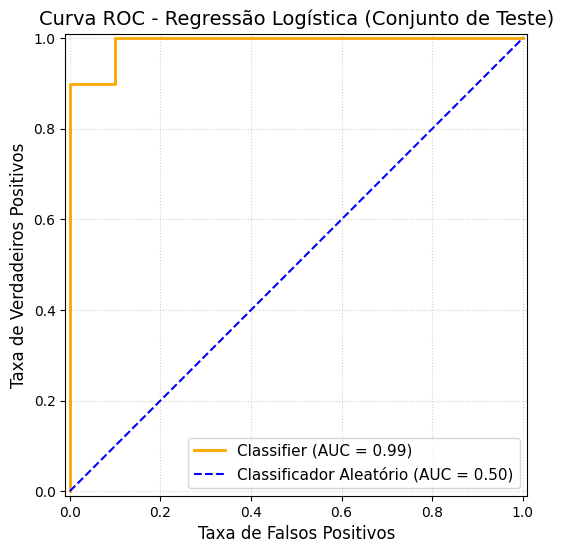

Área Sob a Curva ROC (AUC-ROC): 0.9900


In [124]:
auc_score = roc_auc_score(y_test, prob_positive)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_test,
    prob_positive,
    pos_label='virginica',
    color='orange',
    linewidth=2,
    ax=plt.gca()
)

plt.plot([0, 1], [0, 1], color='blue', linestyle='--', linewidth=1.5, label='Classificador Aleatório (AUC = 0.50)')

plt.title('Curva ROC - Regressão Logística (Conjunto de Teste)', fontsize=14)
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", fontsize=11)
plt.show()

print(f"Área Sob a Curva ROC (AUC-ROC): {auc_score:.4f}")

A avaliação realizada apenas com o threshold de c = 0.5 fornece uma visão mais simple do desempenho do classificador, gerando apenas uma matriz de confusão e métricas derivadas dela, como acurácia, precisão e recall para aquele ponto específico.

A curva ROC, em contrapartida, avalia o desempenho do modelo sob todos os thresholds possíveis simultaneamente. Ela mostra o trade-off entre a Taxa de Verdadeiros Positivos e a Taxa de Falsos Positivos para qualquer ponto.

Portanto, a curva ROC identificar graficamente o threshold ótimo para o cenário desejado, por exemplo, se for mais tolerável aceitar falsos positivos para não perder nenhum verdadeiro positivo, ou vice-versa, orientando a escolha de um limiar diferente de 0.5.